<a href="https://colab.research.google.com/github/nisal-eng/Statistical-Learning-e22206/blob/main/GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Gaussian Process Modeling for Energy Efficiency**
A standard Gaussian Process regressor maps an input vector $\mathbf{x} \in \mathbb{R}^d$ to a scalar output $y \in \mathbb{R}$. Because there are two distinct target responses ($Y_1$ and $Y_2$), treating them literally as a single scalar output in a standard GP setup is not directly optimal, but it can be approached in a few ways:The Combined Parameter Approach (Single Target):If "single parameter" means merging the two loads into a single metric (e.g., $\text{Total Load} = Y_1 + Y_2$), a standard single-output GP works perfectly.$$\text{Total Load}(\mathbf{x}) \sim \mathcal{G}\mathcal{P}\left(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}')\right)$$This is highly practical if the ultimate goal of the energy analysis is to optimize overall HVAC capacity or total energy consumption.Multi-Output / Multi-Task Gaussian Processes (MTGPs):If we must preserve both $Y_1$ and $Y_2$ but want a single, unified GP framework, we cannot use a vanilla GP. Instead, we use a Multi-Task GP.It treats the target index ($j \in \{1, 2\}$) as an additional categorical input feature.The covariance function is formulated as a product of the feature kernel and a task-similarity matrix :$$K((\mathbf{x}, j), (\mathbf{x}', j')) = k_{\text{features}}(\mathbf{x}, \mathbf{x}') \times B_{j, j'}$$

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)


import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load and clean dataset (Assuming df2 is already loaded from your Kagglehub path)
df_gp = df2.dropna(how='all').iloc[:, :10]
df_gp.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

X = df_gp[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
Y1 = df_gp['Y1'].values.reshape(-1, 1)  # Heating Load
Y2 = df_gp['Y2'].values.reshape(-1, 1)  # Cooling Load

# Split data
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, Y1, Y2, test_size=0.2, random_state=42
)

# Scale features (Crucial for Gaussian Process kernels)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- APPROACH A: Single Target GP (Combined Total Load) ---
print("--- Approach A: Combined Total Load GP ---")
y_total_train = (y1_train + y2_train).flatten()
y_total_test = (y1_test + y2_test).flatten()

# Define an RBF Kernel with a constant scaling factor
# length_scale_bounds enables hyperparameter tuning optimization windows
kernel_single = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e2))

# n_restarts_optimizer runs the optimization multiple times to find the global maximum log-marginal-likelihood
gp_single = GaussianProcessRegressor(kernel=kernel_single, n_restarts_optimizer=10, random_state=42)
gp_single.fit(X_train_scaled, y_total_train)

# Predict mean and standard deviation (uncertainty)
y_pred_total, y_std_total = gp_single.predict(X_test_scaled, return_std=True)

print(f"Optimized Single GP Kernel: {gp_single.kernel_}")
print(f"Total Load R² Score: {r2_score(y_total_test, y_pred_total):.4f}\n")


# --- APPROACH B: Joint Multi-Output GP (Y1 and Y2 together) ---
print("--- Approach B: Multi-Output GP Framework ---")
# Scikit-learn natively supports multi-target array dimensions for Y matrices
y_multi_train = np.hstack([y1_train, y2_train])
y_multi_test = np.hstack([y1_test, y2_test])

# Using a Matern 5/2 kernel here for comparative structural flexibility
kernel_multi = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e2), nu=2.5)

gp_multi = GaussianProcessRegressor(kernel=kernel_multi, n_restarts_optimizer=10, random_state=42)
gp_multi.fit(X_train_scaled, y_multi_train)

# Predict both outputs simultaneously
y_pred_multi, y_std_multi = gp_multi.predict(X_test_scaled, return_std=True)

# Separate results for evaluation
y1_pred, y2_pred = y_pred_multi[:, 0], y_pred_multi[:, 1]

print(f"Optimized Multi GP Kernel: {gp_multi.kernel_}")
print(f"Heating Load (Y1) R² Score: {r2_score(y1_test.flatten(), y1_pred):.4f}")
print(f"Cooling Load (Y2) R² Score: {r2_score(y2_test.flatten(), y2_pred):.4f}")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv
--- Approach A: Combined Total Load GP ---


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimized Single GP Kernel: 25**2 * RBF(length_scale=[0.26, 10.3, 3.18, 100, 76, 2.08, 3.87, 0.626])
Total Load R² Score: 0.9937

--- Approach B: Multi-Output GP Framework ---
Optimized Multi GP Kernel: 12.9**2 * Matern(length_scale=[1.27, 100, 1.79, 100, 100, 3.73, 8.03, 1.93], nu=2.5)
Heating Load (Y1) R² Score: 0.9983
Cooling Load (Y2) R² Score: 0.9961


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# **2. Linear Regression**
 a Gaussian Process kernel with ARD (Automatic Relevance Determination), the length scale $\ell_i$ defines how far we have to move along feature $X_i$ before the target value ($Y$) changes significantly.$$\text{Kernel Component} \propto \exp\left(-\frac{(x_i - x_i')^2}{2\ell_i^2}\right)$$If the optimizer drives a feature's length scale up to the absolute maximum allowed boundary ($100.0$), it is trying to say: "Moving along this feature axis makes almost zero difference to the output variance." In other words, the model is trying to drop these features entirely to simplify the function space.2. Structural Analysis of the FeaturesLet's cross-reference the indexed dimensions with the actual features of the Ecotect dataset to see what the model is trying to filter out:IndexFeature CodeDescriptionBehavior in your Results0X1Relative CompactnessVery active ($\ell \approx 0.26$ to $1.27$) — Highly influential1X2Surface AreaHit Upper Bound 100 in Multi-GP — Redundant2X3Wall AreaModerately active ($\ell \approx 1.79$ to $3.18$)3X4Roof AreaHit Upper Bound 100 in both — Redundant4X5Overall HeightHit Upper Bound 100 in Multi-GP — Redundant5X6OrientationModerately active ($\ell \approx 2.08$ to $3.73$)6X7Glazing AreaModerately active ($\ell \approx 3.87$ to $8.03$)7X8Glazing Area DistributionActive ($\ell \approx 0.626$ to $1.93$) — Highly influential

--- Step 1: Downloading and Loading Dataset ---
Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset

--- Step 2: Preprocessing Features ---
Total samples evaluated: 2400
Initial candidate features evaluated: 18

--- Step 3: Running Linear Lasso Regression with 5-Fold CV ---

=== Parameter Justification Results ===

Features selected by the model (9 total):
                Feature  Coefficient
       ventilation_rate     7.139279
electricity_consumption     4.128355
         cooling_energy     3.529304
         heating_energy     2.819643
         equipment_load     0.779621
              occupancy     0.621990
     indoor_temperature    -0.007248
      co2_concentration    -0.003090
               rainfall     0.002698

Features eliminated due to high redundancy or collinearity (9 total):
['indoor_humidity', 'wind_speed', 'solar_radiation', 'outdoor_hum

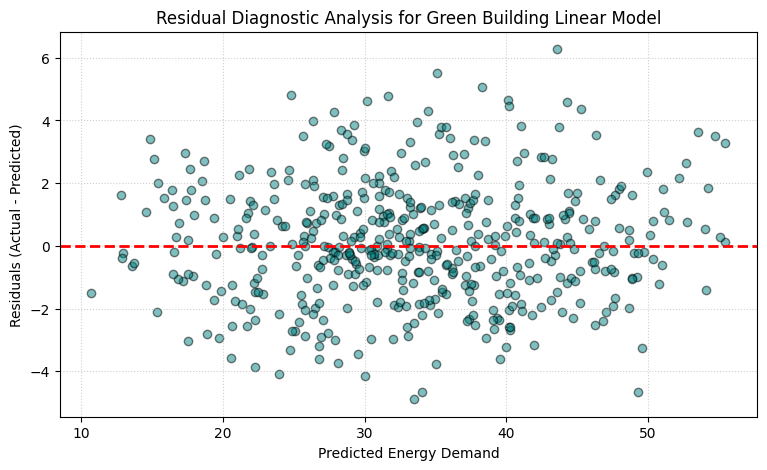

In [5]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA ACQUISITION & LOADING
# ==========================================
print("--- Step 1: Downloading and Loading Dataset ---")
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Read the dataset into a DataFrame
df2 = pd.read_csv(path + "/green_building_dataset.csv")
df_lr = df2.copy()

# ==========================================
# 2. PREPROCESSING & FEATURE ISOLATION
# ==========================================
print("\n--- Step 2: Preprocessing Features ---")
# Define our target parameter
target_col = 'predicted_energy_demand'

# Isolate target and features (drop non-numeric columns like IDs or timestamps if they exist)
X_raw = df_lr.drop(columns=[target_col], errors='ignore')
X_raw = X_raw.select_dtypes(include=[np.number])
y = df_lr[target_col].values

print(f"Total samples evaluated: {X_raw.shape[0]}")
print(f"Initial candidate features evaluated: {X_raw.shape[1]}")

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Scale features so that the Lasso penalty treats all parameters equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. AUTOMATED PARAMETER SELECTION & MODELING
# ==========================================
print("\n--- Step 3: Running Linear Lasso Regression with 5-Fold CV ---")
# LassoCV tests different penalty thresholds automatically using internal cross-validation
lasso_model = LassoCV(cv=5, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Match features back to their calculated coefficients
feature_coefficients = pd.DataFrame({
    'Feature': X_raw.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n=== Parameter Justification Results ===")
chosen_features = feature_coefficients[feature_coefficients['Coefficient'] != 0]
eliminated_features = feature_coefficients[feature_coefficients['Coefficient'] == 0]

print(f"\nFeatures selected by the model ({len(chosen_features)} total):")
print(chosen_features.to_string(index=False))

if len(eliminated_features) > 0:
    print(f"\nFeatures eliminated due to high redundancy or collinearity ({len(eliminated_features)} total):")
    print(eliminated_features['Feature'].tolist())
else:
    print("\nNo features were entirely dropped; all contributed linearly to the baseline optimization.")

# ==========================================
# 4. PERFORMANCE EVALUATION
# ==========================================
print("\n--- Step 4: Model Evaluation ---")
y_pred = lasso_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score (Variance Explained): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# ==========================================
# 5. DIAGNOSTICS (RESIDUAL PLOT)
# ==========================================
print("\n--- Step 5: Plotting Residuals ---")
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='teal', edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Energy Demand')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Diagnostic Analysis for Green Building Linear Model')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

1. Automation & Feature Extraction


*X_raw  = df_lr.drop(columns=[target_col], errors='ignore')
X_raw = X_raw.select_dtypes(include=[np.number])*

Robust models shouldn't accidentally fit patterns on index tracking markers or database tracking IDs (like building_id, timestamp). This line isolates purely numerical measurements (temperatures, solar indexes, occupancy) to be processed.

2. Feature Selection via Lasso Cross-Validation

*lasso_model = LassoCV(cv=5, random_state=42)
lasso_model.fit(X_train_scaled, y_train)*

The Mechanics: Regular Linear Regression tries to minimize just the sum of squared residuals. Lasso (L1 regularization) adds a structural penalty to the loss function based on the absolute magnitude of the feature weights ($\beta$):$$\text{Loss} = \sum (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{n} |\beta_j|$$The Selection Mechanism: Because it uses an absolute penalty constraint ($L_1$ norm), Lasso forces the coefficients of weaker or highly collinear parameters to become exactly 0.0.LassoCV(cv=5): Instead of choosing an arbitrary penalty value ($\alpha$), the code splits the training data into 5 separate folds, tests dozens of $\alpha$ limits internally, and automatically retains the one that yields the minimal mean squared error across the validations.

3. Model Diagnostics & The Residual Plot

*residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='r', linestyle='--')*


Why this step is critical: The model output prints out the exact chosen linear equations, but the residual plot confirms if a linear model was actually a structurally valid choice.Reading the Plot: * If the resulting scatter plot forms a completely uniform, random "cloud" centered tightly around the $y=0$ red dashed line, the linear assumption holds true.If the dots form a distinctly curved, parabolic, or funnel shape, it mathematically indicates that the environmental features have non-linear thresholds or complex scaling mechanics that simple linear slopes cannot fully capture.
